In [5]:
import pickle
import torch
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from tabulate import tabulate
from pathlib import Path

In [6]:
save_dir = Path.cwd() / "data"

In [7]:
mean_reachability_ours, lower_reachability_ours, upper_reachability_ours = pickle.load(open(save_dir / "ours" / "reachability.pkl", "rb"))
mean_deviation_ours, lower_deviation_ours, upper_deviation_ours = pickle.load(open(save_dir / "ours" / "deviation_loss.pkl", "rb"))
mean_reachability_base, lower_reachability_base, upper_reachability_base = pickle.load(open(save_dir / "base" /"reachability.pkl", "rb"))
mean_deviation_base, lower_deviation_base, upper_deviation_base = pickle.load(open(save_dir / "base" / "deviation_loss.pkl", "rb"))
mean_base_runtime, lower_base_runtime, upper_base_runtime = pickle.load(open(save_dir / "base_runtime.pkl", "rb"))
mean_ours_runtime, lower_ours_runtime, upper_ours_runtime = pickle.load(open(save_dir / "ours_runtime.pkl", "rb"))

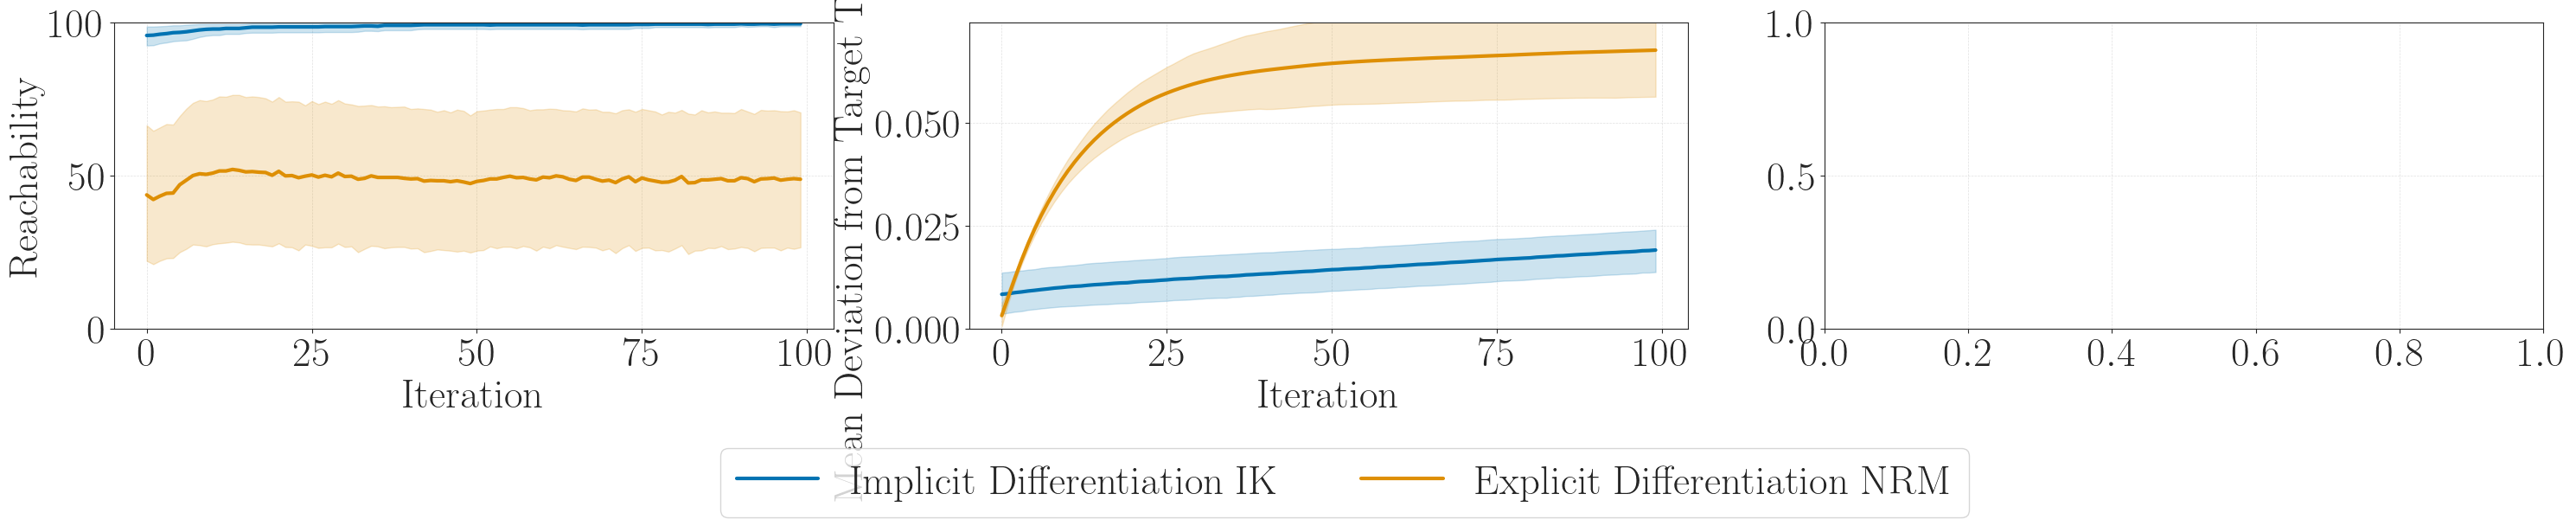

In [10]:
mean_deviation_ours *= 2
lower_deviation_ours *= 2
upper_deviation_ours *= 2
mean_deviation_base *= 2
lower_deviation_base *= 2
upper_deviation_base *= 2

In [ ]:
mean_pose_error_ours, lower_pose_error_ours, upper_pose_error_ours = pickle.load(open(save_dir / "ours" / "pose_error.pkl", "rb"))
mean_self_collision_ours, lower_self_collision_ours, upper_self_collision_ours = pickle.load(open(save_dir / "ours" / "self_collision.pkl", "rb"))
mean_pose_error_base, lower_pose_error_base, upper_pose_error_base = pickle.load(open(save_dir / "base" /"reachability.pkl", "rb"))
mean_self_collision_base, lower_self_collision_base, upper_self_collision_base = pickle.load(open(save_dir / "base" / "self_collision.pkl", "rb"))

In [ ]:
sns.set_style("ticks")
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "pgf.rcfonts": False,
    "text.latex.preamble": r"\usepackage{amsmath}",

    "axes.labelsize": 34,
    "xtick.labelsize": 34,
    "ytick.labelsize": 34,
    "legend.fontsize": 34,
    "axes.titlesize": 34,
    "lines.linewidth": 3,
})


fig, ax = plt.subplots(1, 3, figsize=(30, 5))
colors = sns.color_palette("colorblind", 4)
x = torch.arange(0, 100)
ax[0].plot(x, mean_reachability_base, label=r"$\text{Implicit Differentiation IK}$", color=colors[0])
ax[0].fill_between(x, lower_reachability_base, upper_reachability_base, color=colors[0], alpha=0.2)
ax[0].plot(x, mean_reachability_ours, label=r"$\text{Explicit Differentiation NRM}$", color=colors[1])
ax[0].fill_between(x, lower_reachability_ours, upper_reachability_ours, color=colors[1], alpha=0.2)
ax[0].set_ylabel(r"$\text{Reachability}$")
ax[0].set_xlabel(r"$\text{Iteration}$")
ax[0].set_ylim(0.0, 100.1)

ax[1].plot(x, mean_deviation_base, label=r"$\text{Implicit Differentiation IK}$", color=colors[0])
ax[1].fill_between(x, lower_deviation_base, upper_deviation_base, color=colors[0], alpha=0.2)
ax[1].plot(x, mean_deviation_ours, label=r"$\text{Explicit Differentiation NRM}$", color=colors[1])
ax[1].fill_between(x, lower_deviation_ours, upper_deviation_ours, color=colors[1], alpha=0.2)
ax[1].set_ylim(0.0, 1.1 * mean_deviation_ours.max())
ax[1].set_ylabel(r"$\text{Nominal Deviation}$")
ax[1].set_xlabel(r"$\text{Iteration}$")

x = torch.logspace(0, 4, 10).int()
per_iteration = 100
# ax[2].plot(x, mean_base_runtime/per_iteration, label=r"$\text{Implicit Differentiation IK}$", color=colors[0])
# ax[2].fill_between(x, lower_base_runtime/per_iteration, upper_base_runtime/per_iteration, color=colors[0], alpha=0.2)
# ax[2].plot(x, mean_ours_runtime/per_iteration, label=r"$\text{Explicit Differentiation NRM}$", color=colors[1])
# ax[2].fill_between(x, lower_ours_runtime/per_iteration, upper_ours_runtime/per_iteration, color=colors[1], alpha=0.2)
# ax[2].set_ylabel(r"$\text{Runtime (s)}$")
# ax[2].set_xlabel(r"$\text{\# Task Poses}$")
# ax[2].set_yscale("log")
# ax[2].set_xscale("log")
# ax[2].yaxis.set_major_locator(ticker.LogLocator(base=10.0, numticks=4))
# ax[2].yaxis.set_minor_formatter(ticker.LogFormatterExponent())

for i in range(len(ax)):
    ax[i].grid(True, linestyle='--', alpha=0.6)

handles, labels = ax[0].get_legend_handles_labels()

# Add the legend to the FIGURE, not the AXES
fig.legend(
    handles,
    labels,
    loc='upper center',
    ncol=2,
    bbox_to_anchor=(0.52, 0.0)
)

plt.tight_layout()
plt.savefig("motion_planning.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import torch
import pickle
from matplotlib.lines import Line2D

# --- Style Configuration ---
sns.set_style("ticks")
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "pgf.rcfonts": False,
    "text.latex.preamble": r"\usepackage{amsmath}",

    "axes.labelsize": 34,
    "xtick.labelsize": 34,
    "ytick.labelsize": 34,
    "legend.fontsize": 34,
    "axes.titlesize": 34,
    "lines.linewidth": 3,
})

fig = plt.figure(figsize=(30, 5))

# 1. Create a GridSpec for the whole figure.
# We add extra width to the first column to "absorb" the twin axis label.
gs = fig.add_gridspec(1, 3, width_ratios=[1.1, 1, 1], wspace=0.6)

ax = [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1]), fig.add_subplot(gs[0, 2])]
colors = sns.color_palette("colorblind", 4)
x = torch.arange(0, 100)

# ---------------------------------------------------------
# PLOT 1: POSE ERROR & SELF COLLISIONS (TWIN X)
# ---------------------------------------------------------
ax0_twin = ax[0].twinx()

ax[0].plot(x, mean_pose_error_base, color=colors[0], linestyle='-')
ax[0].plot(x, mean_pose_error_ours, color=colors[1], linestyle='-')
ax[0].fill_between(x, lower_pose_error_base, upper_pose_error_base, color=colors[0], alpha=0.1)
ax[0].fill_between(x, lower_pose_error_ours, upper_pose_error_ours, color=colors[1], alpha=0.1)
ax[0].set_ylabel(r"$\text{Mean Pose Error}$")

ax0_twin.plot(x, mean_self_collision_base, color=colors[0], linestyle=':')
ax0_twin.plot(x, mean_self_collision_ours, color=colors[1], linestyle=':')
ax0_twin.set_ylabel(r"$\text{\# Self Collisions}$", rotation=270, labelpad=45)
ax0_twin.set_ylim([0, 10])
ax0_twin.yaxis.set_major_locator(ticker.MaxNLocator(integer=True, nbins=5))
ax[0].set_xlabel(r"$\text{Iteration}$")

# Style Legend for Plot 1
style_elements_p1 = [
    Line2D([0], [0], color='gray', linestyle='-', label=r"$\text{Mean Pose Error}$"),
    Line2D([0], [0], color='gray', linestyle=':', label=r"$\text{Collisions}$"),
]
ax[0].legend(handles=style_elements_p1, loc='upper right', fontsize=22)

# ---------------------------------------------------------
# PLOT 2: NOMINAL DEVIATION
# ---------------------------------------------------------
ax[1].plot(x, mean_deviation_base, color=colors[0])
ax[1].fill_between(x, lower_deviation_base, upper_deviation_base, color=colors[0], alpha=0.1)
ax[1].plot(x, mean_deviation_ours, color=colors[1])
ax[1].fill_between(x, lower_deviation_ours, upper_deviation_ours, color=colors[1], alpha=0.1)

ax[1].set_ylabel(r"$\text{Nominal Deviation}$")
ax[1].set_xlabel(r"$\text{Iteration}$")

# ---------------------------------------------------------
# PLOT 3: RUNTIME SCALING
# ---------------------------------------------------------
x_runtime = torch.logspace(0, 4, 10).int()
per_iteration = 100
ax[2].plot(x_runtime, mean_base_runtime/per_iteration, color=colors[0])
ax[2].fill_between(x_runtime, lower_base_runtime/per_iteration, upper_base_runtime/per_iteration, color=colors[0], alpha=0.2)
ax[2].plot(x_runtime, mean_ours_runtime/per_iteration, color=colors[1])
ax[2].fill_between(x_runtime, lower_ours_runtime/per_iteration, upper_ours_runtime/per_iteration, color=colors[1], alpha=0.2)

ax[2].set_ylabel(r"$\text{Runtime (s)}$")
ax[2].set_xlabel(r"$\text{\# Task Poses}$")
ax[2].set_yscale("log")
ax[2].set_xscale("log")

# --- CUSTOM UNEVEN SPACING ---
# We force the third plot to move closer to the second plot.
# Bbox: [left, bottom, width, height]
pos2 = ax[1].get_position()
pos3 = ax[2].get_position()

# Shift Plot 3 left by reducing the gap between 2 and 3
# Adjust the 0.05 value to bring them closer or further
ax[2].set_position([pos3.x0 - 0.05, pos3.y0, pos3.width, pos3.height])

# --- Global Polish ---
for i in range(3):
    ax[i].grid(True, linestyle='--', alpha=0.6)

method_elements = [
    Line2D([0], [0], color=colors[0], lw=5, label=r"$\text{Implicit Differentiation IK}$"),
    Line2D([0], [0], color=colors[1], lw=5, label=r"$\text{Explicit Differentiation NRM }$")
]

fig.legend(
    handles=method_elements,
    loc='lower center',
    ncol=2,
    bbox_to_anchor=(0.5, -0.32)
)

# Avoid tight_layout() here as it will override our manual set_position calls
plt.savefig("motion_planning.pdf", format="pdf", bbox_inches="tight")
plt.tight_layout()
plt.show()